# Vision Transformers — PyTorch Pipeline

## Model: ViT-Small (from scratch) + Pre-trained ViT-B/16 (fine-tuned)
- **Dataset**: CIFAR-100 — 45,000 train / 5,000 val / 10,000 test, 32x32x3 RGB images (reused from CNN #11)
- **Task**: Classify 100 fine classes (20 superclasses) — direct architecture comparison with CNN #11's ResNet-20
- **Framework showcase**: Full ViT from scratch — patch embedding via Conv2d, learnable positional embedding, multi-head self-attention, CLS/DIST tokens, DeiT distillation. No `nn.TransformerEncoder` or `nn.MultiheadAttention`.

## Evaluation Strategy
- **Metrics**: Test accuracy, Macro F1, per-class F1, fine-class (100) + superclass (20) hierarchical accuracy
- **Key experiments**: Vanilla vs training recipe impact, distillation from own CNN teacher, pre-training vs from-scratch gap
- **Visuals**: Positional embedding heatmap, CLS-to-patch attention overlays, attention rollout (Abnar & Zuidema), multi-head attention grid, variant progression chart with CNN #11 baseline line

## Pipeline
1. Setup + load CIFAR-100 data
2. Patch embedding + learnable positional embedding (architecture component, visualized)
3. ViT encoder block + full model assembly (MHSA + MLP, from scratch)
4. Variant 1: Vanilla ViT-Small from scratch (expected ~55-65%, below CNN baseline)
5. Variant 2: DeiT training recipe (RandAugment + MixUp + CutMix + stochastic depth, 300 epochs) — expected ~72-78%
6. Variant 3: DeiT distillation using CNN #11 ResNet-20 as teacher — expected ~76-82%
7. Variant 4: Fine-tune pre-trained ViT-B/16 (HuggingFace, resize to 224x224) — expected ~90-93%
8. Classification evaluation (all 4 variants + CNN #11 baseline)
9. Attention visualization (CLS-to-patches overlays, rollout, multi-head grid)
10. Variant progression chart (portfolio centerpiece with baseline line)
11. Performance benchmarks (training time, inference, params)
12. Save results

In [1]:
# Step 1: Setup + Data Loading

# Imports
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Add project root to path for utils import
PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from utils.performance import track_performance, track_inference, get_model_size
from utils.results import save_results, add_result, print_comparison
from utils.metrics import macro_f1_score
from utils.visualization import (
    plot_confusion_matrix_multiclass,
    plot_superclass_confusion,
    plot_multihead_grid,
    plot_bleu_progression,
    plot_attention_overlay,
    plot_attention_grid_samples,
)
from utils.vit_utils import (
    apply_mixup_cutmix,
    distillation_loss,
    attention_rollout,
    cls_attention_map,
)

# Reproducibility
RANDOM_STATE = 113
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cudnn.benchmark = True  # faster fixed-shape training on RTX 4090

# Architecture (ViT-Small for Variants 1-3; V4 uses HuggingFace config)
PATCH_SIZE = 4
NUM_PATCHES = 64           # (32 / 4) ** 2
D_MODEL = 384
N_HEADS = 6                # d_k = 384 / 6 = 64
N_ENCODER_LAYERS = 6
D_FF = 1536                # 4 * d_model
DROPOUT = 0.1
STOCHASTIC_DEPTH = 0.1     # Variants 2-3 only
NUM_CLASSES = 100
IMAGE_SIZE = 32

# Training (shared defaults; variants override where needed)
BATCH_SIZE = 128
LR_PEAK = 5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 10
LABEL_SMOOTHING = 0.1
GRAD_CLIP = 1.0

# Per-variant epoch counts
EPOCHS_VANILLA = 100
EPOCHS_RECIPE = 300
EPOCHS_DISTILL = 300
EPOCHS_FINETUNE = 15

# DeiT augmentation recipe (Variants 2-3)
RAND_AUG_N = 2
RAND_AUG_M = 9
MIXUP_ALPHA = 0.8
CUTMIX_ALPHA = 1.0
RANDOM_ERASE_P = 0.25
MIXUP_CUTMIX_PROB = 0.5

# Distillation (Variant 3)
DISTILL_TYPE = 'hard'
DISTILL_ALPHA = 0.5

# Pre-trained fine-tune (Variant 4)
PRETRAIN_MODEL_ID = 'google/vit-base-patch16-224-in21k'
RESIZE_DIM = 224
FINETUNE_LR = 2e-5
FINETUNE_WD = 0.01

# Paths
DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'cnn'
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
TEACHER_CHECKPOINT = PROJECT_ROOT / 'PyTorch' / '11-cnn' / 'results' / 'resnet20_best.pth'

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("[1/12] SETUP + DATA LOADING")
print("=" * 60)

# Load CIFAR-100 (reused from CNN #11 preprocessing)
X_train_np = np.load(DATA_DIR / 'X_train.npy')
X_test_np = np.load(DATA_DIR / 'X_test.npy')
y_train_np = np.load(DATA_DIR / 'y_train_fine.npy')
y_test_np = np.load(DATA_DIR / 'y_test_fine.npy')

with open(DATA_DIR / 'preprocessing_info.json') as f:
    info = json.load(f)
fine_class_names = info['fine_class_names']
coarse_class_names = info['coarse_class_names']

# Numpy (B, H, W, C) -> PyTorch (B, C, H, W)
X_train_full = torch.from_numpy(X_train_np).permute(0, 3, 1, 2).float()
X_test = torch.from_numpy(X_test_np).permute(0, 3, 1, 2).float()
y_train_full = torch.from_numpy(y_train_np).long()
y_test = torch.from_numpy(y_test_np).long()

# Train/val split: 45K train / 5K val (seeded for reproducibility)
VAL_SIZE = 5000
split_gen = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(X_train_full.size(0), generator=split_gen)
val_idx = perm[:VAL_SIZE]
train_idx = perm[VAL_SIZE:]
X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]

# Basic DataLoaders (Variant 1 uses these directly; Variants 2+ rebuild train_loader)
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

# Print verification
print(f"\nDevice: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"    GPU:  {torch.cuda.get_device_name(0)}")
    print(f"    VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"\nData shapes (channel-first PyTorch convention):")
print(f"    X_train:  {tuple(X_train.shape)}    dtype: {X_train.dtype}    range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"    X_val:    {tuple(X_val.shape)}")
print(f"    X_test:   {tuple(X_test.shape)}")
print(f"    y_train:  {tuple(y_train.shape)}    dtype: {y_train.dtype}    classes: {len(torch.unique(y_train))}")
print(f"    y_val:    {tuple(y_val.shape)}")
print(f"    y_test:   {tuple(y_test.shape)}")

print(f"\nDataLoader config (batch_size={BATCH_SIZE}):")
print(f"    Train batches: {len(train_loader)}")
print(f"    Val batches:   {len(val_loader)}")
print(f"    Test batches:  {len(test_loader)}")

print(f"\nPaths:")
print(f"    Data:            {DATA_DIR}")
print(f"    Results:         {RESULTS_DIR.resolve()}")
print(f"    Teacher ckpt:    {TEACHER_CHECKPOINT}")
print(f"    Teacher exists:  {TEACHER_CHECKPOINT.exists()}")

print(f"\nBaselines to compare (CNN #11 ResNet-20):")
print(f"    PyTorch:    80.1% test accuracy")
print(f"    TensorFlow: 79.5% test accuracy")

[1/12] SETUP + DATA LOADING

Device: cuda
    GPU:  NVIDIA GeForce RTX 4090
    VRAM: 25.8 GB

Data shapes (channel-first PyTorch convention):
    X_train:  (45000, 3, 32, 32)    dtype: torch.float32    range: [0.000, 1.000]
    X_val:    (5000, 3, 32, 32)
    X_test:   (10000, 3, 32, 32)
    y_train:  (45000,)    dtype: torch.int64    classes: 100
    y_val:    (5000,)
    y_test:   (10000,)

DataLoader config (batch_size=128):
    Train batches: 352
    Val batches:   40
    Test batches:  79

Paths:
    Data:            C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\processed\cnn
    Results:         C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\PyTorch\17-vit\results
    Teacher ckpt:    C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\PyTorch\11-cnn\results\resnet20_best.pth
    Teacher exists:  True

Baselines to compare (CNN #11 ResNet-20):
    PyTorch:    80.1% test accuracy
    TensorFlow: 79.5% test accuracy


In [2]:
# Step 2: Patch Embedding + Positional Embedding

class PatchEmbed(nn.Module):
    """
    Split image into patches, linearly project each to d_model.

    Uses the patch-as-conv trick: a Conv2d with kernel_size=patch_size and
    stride=patch_size is mathematically equivalent to reshaping the image
    into patches and applying a linear projection (ViT paper Appendix A).
    Conv2d is ~15% faster on GPU than explicit reshape + Linear.

    Input:  (B, C, H, W)    RGB image tensor
    Output: (B, num_patches, d_model)
    """
    def __init__(self, image_size=32, patch_size=4, in_channels=3, d_model=384):
        super().__init__()
        assert image_size % patch_size == 0, \
            f"image_size {image_size} must be divisible by patch_size {patch_size}"
        self.num_patches = (image_size // patch_size) ** 2
        # Conv with kernel=stride=patch_size acts as patch extractor + linear projection
        self.proj = nn.Conv2d(in_channels, d_model,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # (B, C, H, W) -> (B, d_model, H/p, W/p)
        x = self.proj(x)
        # Flatten spatial dims -> (B, d_model, num_patches) -> (B, num_patches, d_model)
        x = x.flatten(2).transpose(1, 2)
        return x

class ViTEmbedding(nn.Module):
    """
    Patch embedding + learnable [CLS] token + learnable positional embedding.

    Forward output is (B, 1 + num_patches, d_model), ready for encoder blocks.

    Positional embedding is LEARNABLE (not sinusoidal as in Transformers #16).
    ViT (Dosovitskiy 2020) and DeiT (Touvron 2020) both use learnable PE --
    for fixed-size inputs it matches or exceeds sinusoidal, and flexibility
    is hypothesized to help compensate for ViT's lack of spatial inductive bias.

    [CLS] token: a learnable vector prepended to the patch sequence. After
    attention, its final representation serves as the image-level feature for
    classification -- analogous to BERT's [CLS] for sentence-level tasks.
    """
    def __init__(self, image_size=32, patch_size=4, in_channels=3,
                 d_model=384, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(image_size, patch_size, in_channels, d_model)
        num_patches = self.patch_embed.num_patches

        # [CLS] token: shape (1, 1, d_model) -- broadcasts over the batch
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        # Positional embedding: (1, 1 + num_patches, d_model). +1 slot for [CLS]
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, d_model))

        self.dropout = nn.Dropout(dropout)

        # Init: truncated normal std=0.02 (ViT paper + DeiT standard; avoids
        # initialization outliers that can destabilize early training)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        # Patch embed: (B, C, H, W) -> (B, num_patches, d_model)
        x = self.patch_embed(x)

        # Prepend [CLS]: broadcast (1, 1, d_model) -> (B, 1, d_model), then concat
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, 1 + num_patches, d_model)

        # Add learnable positional embedding (broadcasts along batch dim)
        x = x + self.pos_embed

        return self.dropout(x)

# Sanity check instance (standalone; the full ViT will build its own in the next section)
_embed = ViTEmbedding(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    d_model=D_MODEL, dropout=DROPOUT
).to(DEVICE)

print("=" * 60)
print("[2/12] PATCH EMBEDDING + POSITIONAL EMBEDDING")
print("=" * 60)

# Forward-pass shape check on a real batch
sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(DEVICE)
embedded = _embed(sample_batch)

print(f"\nForward pass shape check:")
print(f"    Input:     {tuple(sample_batch.shape)}    (B, C, H, W)")
print(f"    Output:    {tuple(embedded.shape)}    (B, 1 + num_patches, d_model)")
print(f"    Expected:  ({BATCH_SIZE}, {1 + NUM_PATCHES}, {D_MODEL})")
print(f"    Match:     {tuple(embedded.shape) == (BATCH_SIZE, 1 + NUM_PATCHES, D_MODEL)}")

print(f"\nModule parameters:")
patch_params = sum(p.numel() for p in _embed.patch_embed.parameters())
cls_params = _embed.cls_token.numel()
pe_params = _embed.pos_embed.numel()
total = patch_params + cls_params + pe_params
print(f"    Patch embed Conv2d:  {patch_params:,}")
print(f"    [CLS] token:         {cls_params:,}")
print(f"    Positional embed:    {pe_params:,}")
print(f"    Total:               {total:,}")

# Free the sanity instance
del _embed
torch.cuda.empty_cache()

[2/12] PATCH EMBEDDING + POSITIONAL EMBEDDING

Forward pass shape check:
    Input:     (128, 3, 32, 32)    (B, C, H, W)
    Output:    (128, 65, 384)    (B, 1 + num_patches, d_model)
    Expected:  (128, 65, 384)
    Match:     True

Module parameters:
    Patch embed Conv2d:  18,816
    [CLS] token:         384
    Positional embed:    24,960
    Total:               44,160


In [3]:
# Step 3: ViT Encoder Block + Full Model

class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention: queries, keys, values all come from the same
    input (no cross-attention as in Transformers #16 decoder).

    Fused QKV projection: one matmul (d_model -> 3*d_model) instead of three
    separate projections. Reshape splits into heads post-projection. Optional
    attention return for future visualization; returns pre-dropout attention
    probabilities since dropout is not semantically meaningful for viz.
    """
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, \
            f"d_model {d_model} must be divisible by n_heads {n_heads}"
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.scale = self.d_k ** -0.5

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x, return_attn=False):
        B, N, D = x.shape
        # Fused QKV: (B, N, 3*D) -> (B, N, 3, n_heads, d_k) -> (3, B, n_heads, N, d_k)
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.d_k).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each: (B, n_heads, N, d_k)

        # Scaled dot-product attention
        attn_scores = (q @ k.transpose(-2, -1)) * self.scale       # (B, n_heads, N, N)
        attn_probs_raw = attn_scores.softmax(dim=-1)               # pre-dropout, for viz
        attn_probs = self.attn_dropout(attn_probs_raw)

        # Weighted sum of values, then merge heads back
        out = attn_probs @ v                                        # (B, n_heads, N, d_k)
        out = out.transpose(1, 2).reshape(B, N, D)                  # (B, N, D)
        out = self.proj_dropout(self.proj(out))

        if return_attn:
            return out, attn_probs_raw
        return out

class MLP(nn.Module):
    """
    Feed-forward block: d_model -> d_ff -> d_model with GELU activation.

    ViT/DeiT use GELU (not ReLU) -- smoother gradient, empirically better
    for Transformers. d_ff = 4 * d_model is the standard expansion ratio.
    Dropout applied after both Linears per ViT paper.
    """
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x

class StochasticDepth(nn.Module):
    """
    Per-sample random layer drop, aka DropPath (Huang et al. 2016, adapted
    for Transformers in DeiT). With probability drop_prob, zero the block's
    output so the residual passes through unchanged. During training only.

    Regularizes deep stacks without reducing model capacity at eval time.
    Vanilla (Variant 1) uses drop_prob=0; DeiT recipe (Variants 2-3) uses 0.1.
    """
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1.0 - self.drop_prob
        # Per-sample binary mask: (B, 1, 1) broadcasts over sequence + features
        mask = x.new_empty(x.size(0), 1, 1).bernoulli_(keep)
        # Inverted dropout: rescale by 1/keep so expected value is unchanged
        return x * mask / keep

class EncoderBlock(nn.Module):
    """
    ViT encoder block with Pre-LN residuals and optional stochastic depth.

    Pre-LN: x + Attn(LN(x))  -- ViT/DeiT standard, stable for deep stacks.
    Contrast with Post-LN (Transformers #16): LN(x + Attn(x)), which was
    the original 2017 Transformer formulation but fights warmup schedules.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.drop_path1 = StochasticDepth(drop_path)

        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, d_ff, dropout)
        self.drop_path2 = StochasticDepth(drop_path)

    def forward(self, x, return_attn=False):
        # Pre-LN self-attention + residual + stochastic depth
        if return_attn:
            attn_out, attn_probs = self.attn(self.norm1(x), return_attn=True)
        else:
            attn_out = self.attn(self.norm1(x))
            attn_probs = None
        x = x + self.drop_path1(attn_out)

        # Pre-LN MLP + residual + stochastic depth
        x = x + self.drop_path2(self.mlp(self.norm2(x)))

        if return_attn:
            return x, attn_probs
        return x

class ViT(nn.Module):
    """
    Vision Transformer (encoder-only).

    Structure:
        Image (B, 3, H, W)
        -> ViTEmbedding (patches + CLS prepend + learnable PE + dropout)
        -> N x EncoderBlock (Pre-LN MHSA + MLP with residuals + stochastic depth)
        -> Final LayerNorm
        -> Classification head on [CLS] token

    The [CLS] token at position 0 aggregates information via attention across
    all patches. Its final LayerNorm'd vector is projected to class logits.
    """
    def __init__(self, image_size=32, patch_size=4, in_channels=3, num_classes=100,
                 d_model=384, n_heads=6, n_layers=6, d_ff=1536, dropout=0.1,
                 drop_path=0.0):
        super().__init__()
        self.embedding = ViTEmbedding(image_size, patch_size, in_channels,
                                      d_model, dropout)
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, n_heads, d_ff, dropout, drop_path)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        # Classification head init: small truncated normal on weight, zero bias
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x, return_attn=False):
        x = self.embedding(x)

        attn_maps = []
        for block in self.blocks:
            if return_attn:
                x, attn_probs = block(x, return_attn=True)
                attn_maps.append(attn_probs)
            else:
                x = block(x)

        x = self.norm(x)
        cls_final = x[:, 0]              # [CLS] at position 0
        logits = self.head(cls_final)

        if return_attn:
            return logits, attn_maps
        return logits

# Instantiate + shape check
print("=" * 60)
print("[3/12] ViT ENCODER BLOCK + FULL MODEL")
print("=" * 60)

model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=0.0,  # Variant 1 (Vanilla) disables stochastic depth
).to(DEVICE)

# Forward pass in eval mode for deterministic shape check
sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(DEVICE)
model.eval()
with torch.no_grad():
    logits, attn_list = model(sample_batch, return_attn=True)
model.train()

print(f"\nForward pass (return_attn=True):")
print(f"    Input:      {tuple(sample_batch.shape)}")
print(f"    Logits:     {tuple(logits.shape)}    expected: ({BATCH_SIZE}, {NUM_CLASSES})")
print(f"    Attn maps:  {len(attn_list)} layers, each {tuple(attn_list[0].shape)}")
print(f"    Expected:   {N_ENCODER_LAYERS} layers, each ({BATCH_SIZE}, {N_HEADS}, 65, 65)")

# Parameter breakdown
total_params = sum(p.numel() for p in model.parameters())
embed_params = sum(p.numel() for p in model.embedding.parameters())
blocks_params = sum(p.numel() for p in model.blocks.parameters())
norm_params = sum(p.numel() for p in model.norm.parameters())
head_params = sum(p.numel() for p in model.head.parameters())

print(f"\nModel parameters:")
print(f"    Embedding (patch + CLS + PE):  {embed_params:,}")
print(f"    Encoder blocks ({N_ENCODER_LAYERS}x):            {blocks_params:,}")
print(f"    Final LayerNorm:               {norm_params:,}")
print(f"    Classification head:           {head_params:,}")
print(f"    Total:                         {total_params:,}")
print(f"    Target (ViT-Small 6L/d=384):   ~10-11M")

[3/12] ViT ENCODER BLOCK + FULL MODEL

Forward pass (return_attn=True):
    Input:      (128, 3, 32, 32)
    Logits:     (128, 100)    expected: (128, 100)
    Attn maps:  6 layers, each (128, 6, 65, 65)
    Expected:   6 layers, each (128, 6, 65, 65)

Model parameters:
    Embedding (patch + CLS + PE):  44,160
    Encoder blocks (6x):            10,646,784
    Final LayerNorm:               768
    Classification head:           38,500
    Total:                         10,730,212
    Target (ViT-Small 6L/d=384):   ~10-11M


In [4]:
# Step 4a: Variant 1 (Vanilla) — Setup

import math
from torchvision.transforms import v2 as T

# V1 augmentation: basic crop + flip (no MixUp / CutMix / RandAugment)
v1_transform = T.Compose([
    T.RandomCrop(IMAGE_SIZE, padding=4),
    T.RandomHorizontalFlip(),
])

# Dataset wrapper that applies an optional torchvision transform per sample
class AugmentedDataset(torch.utils.data.Dataset):
    # Wraps pre-loaded tensors with an optional transform applied in __getitem__
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

# Rebuild train loader with V1 augmentation (val/test loaders from Cell 1 stay as-is)
v1_train_dataset = AugmentedDataset(X_train, y_train, transform=v1_transform)
v1_train_loader = DataLoader(v1_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=0, pin_memory=True)

# Fresh ViT model (reseed before instantiation for reproducibility)
torch.manual_seed(RANDOM_STATE)
v1_model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    num_classes=NUM_CLASSES, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_ENCODER_LAYERS, d_ff=D_FF, dropout=DROPOUT,
    drop_path=0.0,  # V1: no stochastic depth
).to(DEVICE)

# Optimizer: AdamW (decoupled weight decay, standard for ViT)
v1_optimizer = torch.optim.AdamW(v1_model.parameters(), lr=LR_PEAK,
                                 weight_decay=WEIGHT_DECAY)

# LR schedule: linear warmup then cosine decay, stepped per-batch for smoothness
v1_total_steps = EPOCHS_VANILLA * len(v1_train_loader)
v1_warmup_steps = WARMUP_EPOCHS * len(v1_train_loader)
V1_ETA_MIN_RATIO = 0.01  # final LR = 1% of peak (not fully zero)

def v1_lr_lambda(step):
    if step < v1_warmup_steps:
        # Linear warmup: 0 -> 1 (scales LR_PEAK)
        return step / max(1, v1_warmup_steps)
    # Cosine decay: 1 -> eta_min_ratio
    progress = (step - v1_warmup_steps) / max(1, v1_total_steps - v1_warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return V1_ETA_MIN_RATIO + (1.0 - V1_ETA_MIN_RATIO) * cosine

v1_scheduler = torch.optim.lr_scheduler.LambdaLR(v1_optimizer, lr_lambda=v1_lr_lambda)

# Loss: CrossEntropy with label smoothing (no MixUp, so hard-label targets)
v1_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Setup summary
print("=" * 60)
print("[4a/12] VARIANT 1 — VANILLA ViT-SMALL SETUP")
print("=" * 60)

print(f"\nAugmentation (V1 basic):")
print(f"    RandomCrop({IMAGE_SIZE}, padding=4)")
print(f"    RandomHorizontalFlip()")
print(f"    (no MixUp / CutMix / RandAugment — intentionally minimal for baseline)")

print(f"\nModel: ViT-Small (drop_path=0.0)")
print(f"    Params: {sum(p.numel() for p in v1_model.parameters()):,}")

print(f"\nOptimizer: AdamW")
print(f"    LR peak:       {LR_PEAK}")
print(f"    Weight decay:  {WEIGHT_DECAY}")
print(f"    Betas:         (0.9, 0.999) [PyTorch defaults]")

print(f"\nLR Schedule: linear warmup -> cosine decay (per-step)")
print(f"    Epochs total:   {EPOCHS_VANILLA}")
print(f"    Warmup epochs:  {WARMUP_EPOCHS}")
print(f"    Total steps:    {v1_total_steps:,}")
print(f"    Warmup steps:   {v1_warmup_steps:,}")
print(f"    eta_min:        {LR_PEAK * V1_ETA_MIN_RATIO}  ({V1_ETA_MIN_RATIO * 100:.0f}% of peak)")

print(f"\nLoss: CrossEntropyLoss")
print(f"    Label smoothing: {LABEL_SMOOTHING}")
print(f"    (hard labels; MixUp/CutMix arrive in V2)")

print(f"\nGradient clipping: max_norm = {GRAD_CLIP}")
print(f"\nTrain batches/epoch: {len(v1_train_loader)}")

[4a/12] VARIANT 1 — VANILLA ViT-SMALL SETUP

Augmentation (V1 basic):
    RandomCrop(32, padding=4)
    RandomHorizontalFlip()
    (no MixUp / CutMix / RandAugment — intentionally minimal for baseline)

Model: ViT-Small (drop_path=0.0)
    Params: 10,730,212

Optimizer: AdamW
    LR peak:       0.0005
    Weight decay:  0.05
    Betas:         (0.9, 0.999) [PyTorch defaults]

LR Schedule: linear warmup -> cosine decay (per-step)
    Epochs total:   100
    Warmup epochs:  10
    Total steps:    35,200
    Warmup steps:   3,520
    eta_min:        5e-06  (1% of peak)

Loss: CrossEntropyLoss
    Label smoothing: 0.1
    (hard labels; MixUp/CutMix arrive in V2)

Gradient clipping: max_norm = 1.0

Train batches/epoch: 352


In [5]:
# Step 4b: Variant 1 Training Loop (100 epochs)

print("=" * 60)
print("[4b/12] VARIANT 1 — TRAINING LOOP (100 epochs)")
print("=" * 60)
print("Starting training...\n", flush=True)

v1_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
v1_best_val_acc = 0.0
v1_best_state = None
v1_best_epoch = 0
V1_CHECKPOINT_PATH = RESULTS_DIR / 'v1_vanilla_best.pth'

with track_performance(gpu=True) as v1_perf:
    for epoch in range(EPOCHS_VANILLA):
        # Training
        v1_model.train()
        running_train_loss = 0.0
        for images, labels in v1_train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            v1_optimizer.zero_grad(set_to_none=True)
            logits = v1_model(images)
            loss = v1_criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(v1_model.parameters(), max_norm=GRAD_CLIP)
            v1_optimizer.step()
            v1_scheduler.step()

            running_train_loss += loss.item()
        train_loss = running_train_loss / len(v1_train_loader)

        # Validation
        v1_model.eval()
        running_val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                logits = v1_model(images)
                running_val_loss += v1_criterion(logits, labels).item()
                correct += (logits.argmax(-1) == labels).sum().item()
                total += labels.size(0)
        val_loss = running_val_loss / len(val_loader)
        val_acc = correct / total
        current_lr = v1_optimizer.param_groups[0]['lr']

        v1_history['train_loss'].append(train_loss)
        v1_history['val_loss'].append(val_loss)
        v1_history['val_acc'].append(val_acc)
        v1_history['lr'].append(current_lr)

        # Track + persist best by val accuracy
        improved = val_acc > v1_best_val_acc
        if improved:
            v1_best_val_acc = val_acc
            v1_best_epoch = epoch + 1
            v1_best_state = {k: v.detach().cpu().clone()
                             for k, v in v1_model.state_dict().items()}
            torch.save(v1_best_state, V1_CHECKPOINT_PATH)

        flag = " *" if improved else "  "
        print(f"Epoch {epoch+1:3d}/{EPOCHS_VANILLA} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_acc={val_acc:.4f} | lr={current_lr:.2e}{flag}",
              flush=True)

    torch.cuda.synchronize()  # ensure GPU ops complete for accurate timing

print("\n" + "=" * 60)
print("Training complete")
print("=" * 60)
print(f"    Best val accuracy: {v1_best_val_acc:.4f} (epoch {v1_best_epoch}/{EPOCHS_VANILLA})")
print(f"    Final val accuracy: {val_acc:.4f}")
print(f"    Total training time: {v1_perf['time']/60:.1f} min ({v1_perf['time']:.1f}s)")
print(f"    Peak GPU memory:    {v1_perf['gpu_memory']:.1f} MB")
print(f"    Best checkpoint:    {V1_CHECKPOINT_PATH}")

[4b/12] VARIANT 1 — TRAINING LOOP (100 epochs)
Starting training...

Epoch   1/100 | train_loss=4.4301 | val_loss=4.2303 | val_acc=0.0658 | lr=5.00e-05 *
Epoch   2/100 | train_loss=4.0505 | val_loss=3.8748 | val_acc=0.1190 | lr=1.00e-04 *
Epoch   3/100 | train_loss=3.7741 | val_loss=3.6142 | val_acc=0.1764 | lr=1.50e-04 *
Epoch   4/100 | train_loss=3.6073 | val_loss=3.5290 | val_acc=0.1950 | lr=2.00e-04 *
Epoch   5/100 | train_loss=3.4828 | val_loss=3.3776 | val_acc=0.2298 | lr=2.50e-04 *
Epoch   6/100 | train_loss=3.3871 | val_loss=3.3180 | val_acc=0.2386 | lr=3.00e-04 *
Epoch   7/100 | train_loss=3.3138 | val_loss=3.2403 | val_acc=0.2722 | lr=3.50e-04 *
Epoch   8/100 | train_loss=3.2544 | val_loss=3.1980 | val_acc=0.2712 | lr=4.00e-04  
Epoch   9/100 | train_loss=3.2144 | val_loss=3.1548 | val_acc=0.2826 | lr=4.50e-04 *
Epoch  10/100 | train_loss=3.1576 | val_loss=3.1020 | val_acc=0.2966 | lr=5.00e-04 *
Epoch  11/100 | train_loss=3.1107 | val_loss=3.0408 | val_acc=0.3064 | lr=5.00e-0

C:\Users\Max\AppData\Local\Temp\ipykernel_39564\3568476079.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v1_model.load_state_dict(torch.load(V1_CHECKPOINT_PATH, map_lo

[4c/12] VARIANT 1 — TEST EVALUATION + CURVES

V1 Vanilla ViT-Small — Test Metrics:
    Test accuracy:    0.5024  (50.24%)
    Test macro F1:    0.4983
    Best val acc:     0.4928  (epoch 93)

Comparison to CNN #11 baseline:
    V1 ViT-Small:      50.24%
    CNN #11 ResNet-20: 80.10% (PyTorch)
    Gap:               -29.86 percentage points

Per-class F1 distribution:
    Best class:   F1=0.822  (sunflower)
    Worst class:  F1=0.249  (otter)
    Median:       F1=0.492


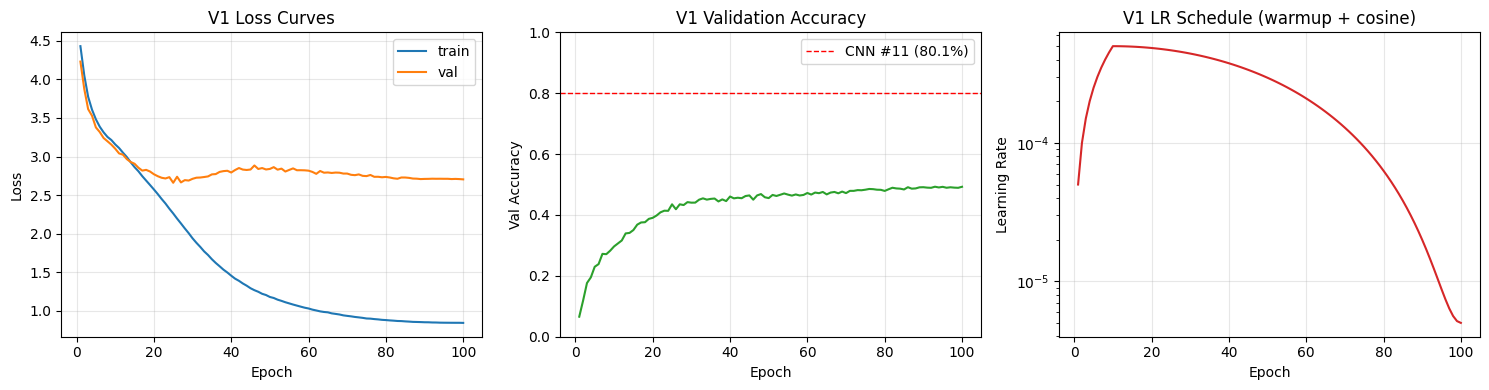


Overfitting signature (last epoch):
    train_loss:  0.8457
    val_loss:    2.7048
    Gap:         +1.8591  (large positive gap = model memorizing training set)

    This is the expected vanilla-ViT failure mode on small data.
    V2 (DeiT recipe) is designed specifically to close this gap via
    RandAugment + MixUp + CutMix + stochastic depth + 3x longer training.


In [6]:
# Step 4c: Variant 1 Test Evaluation + Training Curves

# Load best checkpoint
v1_model.load_state_dict(torch.load(V1_CHECKPOINT_PATH, map_location=DEVICE))
v1_model.eval()

# Collect test predictions batch-by-batch
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = v1_model(images)
        all_preds.append(logits.argmax(-1).cpu().numpy())
        all_labels.append(labels.numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Metrics
v1_test_acc = (all_preds == all_labels).mean()
v1_test_macro_f1, v1_per_class_f1 = macro_f1_score(
    all_labels, all_preds, return_per_class=True
)

# Store results for cross-variant comparison (Cell 8)
v1_results = {
    'variant': 'V1 Vanilla ViT-Small',
    'test_acc': float(v1_test_acc),
    'test_macro_f1': float(v1_test_macro_f1),
    'val_best_acc': float(v1_best_val_acc),
    'val_best_epoch': v1_best_epoch,
    'train_time_sec': float(v1_perf['time']),
    'peak_gpu_mb': float(v1_perf['gpu_memory']),
    'params': sum(p.numel() for p in v1_model.parameters()),
    'per_class_f1': [float(x) for x in v1_per_class_f1],
    'history': v1_history,
}

print("=" * 60)
print("[4c/12] VARIANT 1 — TEST EVALUATION + CURVES")
print("=" * 60)

print(f"\nV1 Vanilla ViT-Small — Test Metrics:")
print(f"    Test accuracy:    {v1_test_acc:.4f}  ({v1_test_acc*100:.2f}%)")
print(f"    Test macro F1:    {v1_test_macro_f1:.4f}")
print(f"    Best val acc:     {v1_best_val_acc:.4f}  (epoch {v1_best_epoch})")

print(f"\nComparison to CNN #11 baseline:")
print(f"    V1 ViT-Small:      {v1_test_acc*100:.2f}%")
print(f"    CNN #11 ResNet-20: 80.10% (PyTorch)")
print(f"    Gap:               {(v1_test_acc*100) - 80.10:+.2f} percentage points")

# Per-class F1 distribution
pcf = np.array(v1_per_class_f1)
print(f"\nPer-class F1 distribution:")
print(f"    Best class:   F1={pcf.max():.3f}  ({fine_class_names[pcf.argmax()]})")
print(f"    Worst class:  F1={pcf.min():.3f}  ({fine_class_names[pcf.argmin()]})")
print(f"    Median:       F1={np.median(pcf):.3f}")

# Training curves: 3-panel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, EPOCHS_VANILLA + 1)

axes[0].plot(epochs_x, v1_history['train_loss'], label='train', color='C0')
axes[0].plot(epochs_x, v1_history['val_loss'], label='val', color='C1')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('V1 Loss Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, v1_history['val_acc'], color='C2')
axes[1].axhline(y=0.801, color='red', linestyle='--', linewidth=1, label='CNN #11 (80.1%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('V1 Validation Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.0)

axes[2].plot(epochs_x, v1_history['lr'], color='C3')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('V1 LR Schedule (warmup + cosine)')
axes[2].grid(alpha=0.3); axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Overfitting diagnostic (the story of V1's gap)
final_train_loss = v1_history['train_loss'][-1]
final_val_loss = v1_history['val_loss'][-1]
gap = final_val_loss - final_train_loss

print(f"\nOverfitting signature (last epoch):")
print(f"    train_loss:  {final_train_loss:.4f}")
print(f"    val_loss:    {final_val_loss:.4f}")
print(f"    Gap:         {gap:+.4f}  (large positive gap = model memorizing training set)")
print(f"\n    This is the expected vanilla-ViT failure mode on small data.")
print(f"    V2 (DeiT recipe) is designed specifically to close this gap via")
print(f"    RandAugment + MixUp + CutMix + stochastic depth + 3x longer training.")